# Nucleus 1000 ins data to keypoints

In [1]:
import numpy as np
import pandas as pd
from tools.bag_to_df import bag_topic_to_dataframe
import matplotlib.pyplot as plt 
from tools.tools import *
from dataclasses import dataclass
from scipy.spatial.transform import Rotation as R
from tools.tools import print_bag_topics
from tools.signal_properties import compare_signals


%load_ext autoreload
%autoreload 2

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


# Load BAG

In [2]:
bagdir = "/root/stonefish_ros2_ws/sintef_dataset/2024-08-22_14-29-05_data.bag"
print_bag_topics(bagdir)

Topics and message types:
/bluerov2/alive                                std_msgs/msg/Float32
/bluerov2/armed                                std_msgs/msg/Float32
/bluerov2/battery                              messages/msg/BatteryStatus
/bluerov2/modes                                joystick/msg/ModeManager2
/commanded_thrust                              rospy_tutorials/msg/Floats
/controller/x                                  messages/msg/MRACOupdate
/controller/y                                  messages/msg/MRACOupdate
/controller/yaw                                messages/msg/PIDState
/controller/z                                  messages/msg/PIDState
/gui/netFollowing_manager                      messages/msg/NetFollowingManager
/guidance                                      messages/msg/GuidanceManager
/joystick                                      joystick/msg/Joystick
/joystick/dvl_reset_position                   messages/msg/BoolStamped
/joystick/init                        

# Read data

In [3]:
dvl_position = bag_topic_to_dataframe(bagdir, topic="/sensor/dvl_position")
dvl_velocity = bag_topic_to_dataframe(bagdir, topic="/sensor/dvl_velocity")
nucleus_altitude = bag_topic_to_dataframe(bagdir, topic="/nucleus1000dvl/altimeter")
plane_position = bag_topic_to_dataframe(bagdir, topic="/navigation/plane_approximation_position")
plane_approximation = bag_topic_to_dataframe(bagdir, topic="/navigation/plane_approximation")

/root/stonefish_ros2_ws/plots/tools/bag_to_df.py:236: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors='ignore')


# Nucleus 1000 INS

## Transform

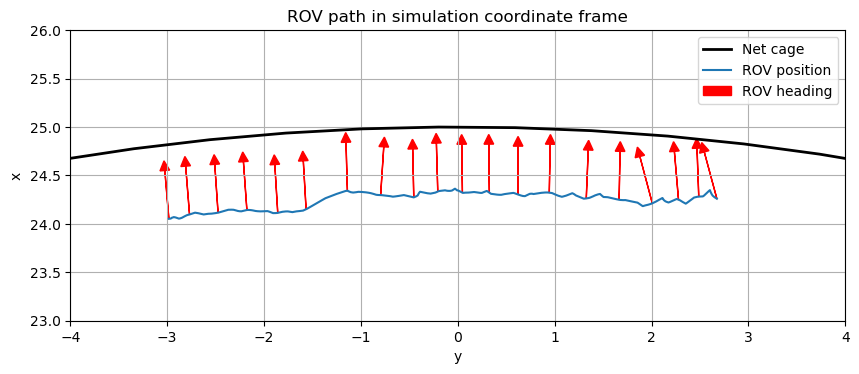

In [4]:
from tools.data import Nucleus

xyz_post = np.array([23.6688, 4.5, 0])
rpy_post = np.array([0, 0, -2.1])

ins_data = Nucleus(bagdir, xyz_post, rpy_post)

# --------- PLOT ---------
plt.figure(figsize=(10,10))
plot_net()
plt.plot(ins_data.y, ins_data.x, label="ROV position")
plot_heading_arrows(ins_data.xyz, ins_data.rpy)

plt.grid()
plt.title("ROV path in simulation coordinate frame")
plt.xlabel("y")
plt.ylabel("x")

plt.ylim(23, 26)
plt.xlim(-4, 4)

plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

# Filter and downsample

Num. keypoints: 57
{'rmse': 22.39462151079133, 'corr': -0.47900252996706977, 'mean1': 24.244829835781523, 'mean2': 1.8505173077468084, 'mean_error': 22.394312528034718, 'var_signal1': 0.0071719540877263, 'var_signal2': 0.0025688668724256373, 'var_difference': 0.004603087215300662, 'var_ratio_s1_over_s2': 2.79187456723058, 'cv_signal1': 0.0034930082390301482, 'cv_signal2': 0.02738909281464946, 'kurtosis_signal1': -0.8568126585595057, 'kurtosis_signal2': -1.7615001649984348, 'kurtosis_difference': 0.904687506438929}
{'rmse': 22.39454989581996, 'corr': -0.4791275682961247, 'mean1': 24.24475974306021, 'mean2': 1.8505173077468084, 'mean_error': 22.394242435313405, 'var_signal1': 0.0071180694195567065, 'var_signal2': 0.0025688668724256373, 'var_difference': 0.004549202547131069, 'var_ratio_s1_over_s2': 2.770898521820055, 'cv_signal1': 0.0034798716411794627, 'cv_signal2': 0.02738909281464946, 'kurtosis_signal1': -0.8541020428147115, 'kurtosis_signal2': -1.7615001649984348, 'kurtosis_differenc

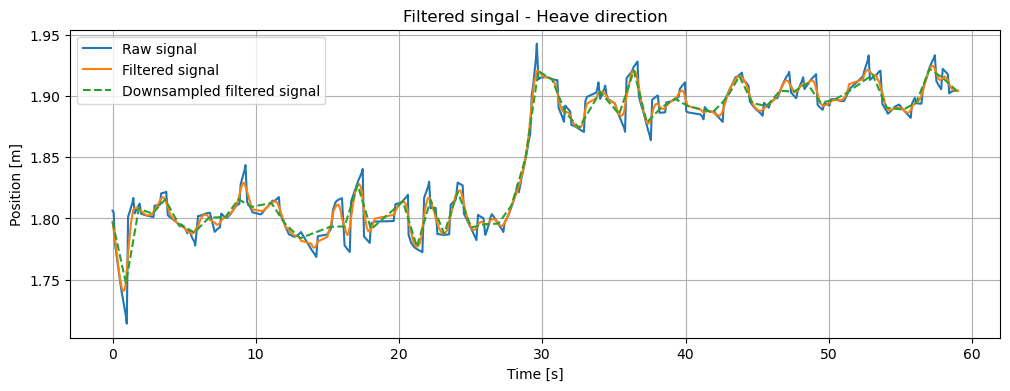

In [5]:
plt.figure(figsize=(12, 4))

# Set t0 to be 0
ins_data.start_at_t_zero()

t_ds, xyz_ds, rpy_ds = ins_data.get_downsapled_filtered_xyz_rpy(every_n=10)
x_ds = xyz_ds[:,2]

plt.plot(ins_data.t, ins_data.z, label="Raw signal")
plt.plot(ins_data.t, ins_data.z_f, label="Filtered signal")
plt.plot(t_ds, x_ds, label="Downsampled filtered signal", ls="--")

plt.title("Filtered singal - Heave direction")
plt.xlabel("Time [s]")
plt.ylabel("Position [m]")

plt.legend()
plt.grid()

comp_raw = compare_signals(ins_data.t, ins_data.x,
                       t_ds, x_ds)

comp_ds = compare_signals(ins_data.t, ins_data.x_f,
                       t_ds, x_ds)

print(comp_raw)
print(comp_ds)

# Verify with real data

Mean net distance error: 2.5680268292638253e-05


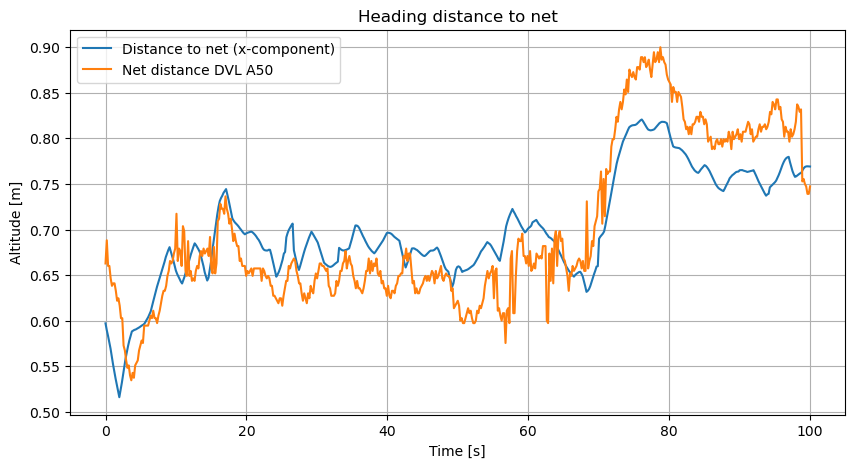

In [6]:
# We want to compare distances from a common point (IMU)
# Transform data from A50 to common point

def dist_to_net(y_pos):
    r = 25
    return np.sqrt(r**2 - y_pos**2)

dist = []

for x, y in zip(ins_data.x, ins_data.y):
    distance = dist_to_net(y) - x
    dist.append(distance)

imu_to_a50_xdir = 0.1
dvl_altitude = dvl_velocity["altitude"].values + imu_to_a50_xdir


mean_diff = np.abs(np.mean(dvl_altitude) - np.mean(dist))
print(f"Mean net distance error: {mean_diff}")

plt.figure(figsize=(10, 5))
plt.title("Heading distance to net")
plt.plot(np.linspace(0, 100, len(ins_data.x)), dist, label="Distance to net (x-component)")
plt.plot(np.linspace(0, 100, len(dvl_altitude)), dvl_altitude, label="Net distance DVL A50")
plt.xlabel("Time [s]")
plt.ylabel("Altitude [m]")
plt.grid()
plt.legend()


# To file

In [9]:
ins_data.write_keypoints(every_n=10, win_sec=1)

Num. keypoints: 57
Wrote 57 keypoints to /root/stonefish_ros2_ws/plots/keypoints.txt
